# 14장 실습 ② — GAN

**Keras 3 판**

두 모델이 서로를 이기려 합니다. 그 다툼에서 그림이 나옵니다.

> **주의 — 이 노트북의 손실 곡선은 「내려가면 좋은 것」이 아닙니다.**

## 14.0 준비

In [1]:
try:
    import dlbook
except ImportError:
    !pip install -q "dlbook @ git+https://github.com/dhrim/deep-learning-in-one-semester.git"
    import dlbook

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import dlbook
from dlbook import data, metrics, plot

dlbook.set_seed(42)
plot.use_korean()
print(dlbook.versions())

{'python': '3.12.3', 'numpy': '2.1.3', 'keras': '3.15.1', 'tensorflow': '2.21.0', 'torch': '-', 'keras_backend': 'tensorflow'}


## 14.1 데이터와 지표

**다양성 지표**를 먼저 정의합니다. 생성물끼리 얼마나 다른지 재는 값입니다.
모드 붕괴를 눈이 아니라 **숫자로** 보기 위해서입니다.

In [3]:
LATENT = 32

s = data.mnist()
x_train = s.x_train.reshape(-1, 784) * 2 - 1     # tanh 출력에 맞춰 [-1, 1]
print(f"학습 {x_train.shape}, 범위 [{x_train.min():.0f}, {x_train.max():.0f}]")

def show(rows, titles, n=8):
    fig, axes = plt.subplots(len(rows), n, figsize=(1.15 * n, 1.25 * len(rows)))
    axes = np.atleast_2d(axes)
    for r, (imgs, t) in enumerate(zip(rows, titles)):
        for c in range(n):
            axes[r, c].imshow(imgs[c].reshape(28, 28), cmap="gray", vmin=-1, vmax=1)
            axes[r, c].axis("off")
        axes[r, 0].axis("on"); axes[r, 0].set_xticks([]); axes[r, 0].set_yticks([])
        axes[r, 0].set_ylabel(t, fontsize=9)
    plt.tight_layout(); plt.show()

def diversity(A, n=300, seed=1):
    """생성물끼리의 평균 거리. **모드 붕괴를 재는 가장 간단한 지표.**

    다 비슷하게 생겼으면 이 값이 작아진다.
    """
    idx = np.random.default_rng(seed).choice(len(A), min(n, len(A)), replace=False)
    B = A[idx]
    d = np.sqrt(((B[:, None, :] - B[None, :, :]) ** 2).sum(-1))
    return float(d[np.triu_indices(len(B), 1)].mean())

REAL_DIV = diversity(x_train[:2000])
print(f"진짜 숫자끼리의 평균 거리 {REAL_DIV:.3f}  ← 이것이 목표치입니다")
dlbook.record("ch14_real_diversity", REAL_DIV)

학습 (54000, 784), 범위 [-1, 1]


진짜 숫자끼리의 평균 거리 20.289  ← 이것이 목표치입니다
ch14_real_diversity = 20.2895


20.28948402404785

## 14.2 모델과 학습 루프 — 여기만 판마다 다릅니다

**세 판의 차이가 이 장에서 가장 큽니다.**

| 판 | 방식 |
|---|---|
| Keras 3 | `keras.Model` 을 상속해 `train_step` 만 다시 씁니다 |
| TensorFlow | `tf.function` + `GradientTape` 를 직접 씁니다 |
| PyTorch | 걸음마다 손으로 씁니다 — **가장 훤히 보입니다** |

GAN처럼 **한 걸음에 두 모델을 번갈아 갱신**해야 하는 경우,
`fit()` 한 줄로는 안 됩니다.

In [4]:
import keras
from keras import layers, ops

def make_generator(latent):
    """잡음 → 그림. **이 함수만 판마다 다릅니다.**"""
    return keras.Sequential([
        layers.Input(shape=(latent,)),
        layers.Dense(128, activation="relu"),
        layers.Dense(256, activation="relu"),
        layers.Dense(784, activation="tanh"),
    ], name="generator")

def make_discriminator():
    """그림 → 진짜일 로짓."""
    return keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(256, activation="leaky_relu"),
        layers.Dense(128, activation="leaky_relu"),
        layers.Dense(1),
    ], name="discriminator")

class GAN(keras.Model):
    """Keras 3 의 방식 — train_step 하나만 바꿉니다.

    fit() 는 그대로 쓰면서 **한 걸음에 무엇을 할지**만 다시 씁니다.
    백엔드(TensorFlow/PyTorch/JAX)와 무관하게 돕니다.
    """
    def __init__(self, generator, discriminator, latent):
        super().__init__()
        self.G, self.D, self.latent = generator, discriminator, latent
        self.d_loss = keras.metrics.Mean(name="d_loss")
        self.g_loss = keras.metrics.Mean(name="g_loss")

    @property
    def metrics(self):
        return [self.d_loss, self.g_loss]

    def compile(self, d_opt, g_opt):
        super().compile()
        self.d_opt, self.g_opt = d_opt, g_opt
        self.bce = keras.losses.BinaryCrossentropy(from_logits=True)

    def _d_loss(self, real, fake):
        return (self.bce(ops.ones_like(self.D(real)), self.D(real))
                + self.bce(ops.zeros_like(self.D(fake)), self.D(fake)))

    def train_step(self, real):
        n = ops.shape(real)[0]

        # ① 판별기 — 진짜는 1, 가짜는 0 이라고 답하도록
        z = keras.random.normal((n, self.latent))
        fake = self.G(z)
        dl, grads = self._grad(lambda: self._d_loss(real, fake),
                               self.D.trainable_weights)
        self.d_opt.apply_gradients(zip(grads, self.D.trainable_weights))

        # ② 생성기 — 판별기가 **1이라고 답하도록**
        z = keras.random.normal((n, self.latent))
        def gloss():
            out = self.D(self.G(z))
            return self.bce(ops.ones_like(out), out)
        gl, grads = self._grad(gloss, self.G.trainable_weights)
        self.g_opt.apply_gradients(zip(grads, self.G.trainable_weights))

        self.d_loss.update_state(dl); self.g_loss.update_state(gl)
        return {"d_loss": self.d_loss.result(), "g_loss": self.g_loss.result()}

    def _grad(self, fn, weights):
        """백엔드에 맞는 방식으로 (손실, 기울기) 를 구한다."""
        if keras.backend.backend() == "tensorflow":
            import tensorflow as tf
            with tf.GradientTape() as tape:
                loss = fn()
            return loss, tape.gradient(loss, weights)
        import torch
        loss = fn()
        for w in weights:
            if w.value.grad is not None:
                w.value.grad = None
        loss.backward()
        return loss, [w.value.grad for w in weights]

def train_gan(x, latent, epochs=30, checkpoints=(1, 5, 30),
              lr=2e-4, batch=128, seed=42, diversity_fn=None):
    dlbook.set_seed(seed)
    G, D = make_generator(latent), make_discriminator()
    gan = GAN(G, D, latent)
    gan.compile(d_opt=keras.optimizers.Adam(lr, beta_1=0.5),
                g_opt=keras.optimizers.Adam(lr, beta_1=0.5))
    z_fix = np.random.default_rng(0).normal(size=(500, latent)).astype("float32")
    hist = []
    for e in range(1, epochs + 1):
        h = gan.fit(x, batch_size=batch, epochs=1, verbose=0)
        if e in checkpoints:
            div = diversity_fn(generate(G, z_fix)) if diversity_fn else 0.0
            hist.append((e, float(h.history["d_loss"][-1]),
                         float(h.history["g_loss"][-1]), div))
    return G, D, hist

def generate(G, z):
    return np.asarray(G.predict(z, verbose=0))

def train_autoencoder(x, latent, epochs=15, seed=42):
    dlbook.set_seed(seed)
    enc = keras.Sequential([layers.Input(shape=(784,)),
                            layers.Dense(128, activation="relu"),
                            layers.Dense(latent, activation="relu")])
    dec = keras.Sequential([layers.Input(shape=(latent,)),
                            layers.Dense(128, activation="relu"),
                            layers.Dense(784, activation="tanh")])
    ae = keras.Sequential([enc, dec])
    ae.compile(optimizer=keras.optimizers.Adam(0.001), loss="mse")
    ae.fit(x, x, epochs=dlbook.smoke.epochs(epochs), batch_size=256, verbose=0)
    return enc, dec

def encode(enc, x):
    return np.asarray(enc.predict(x, verbose=0))

def decode(dec, z):
    return np.asarray(dec.predict(z, verbose=0))

## 14.3 GAN 학습

In [5]:
# GAN 학습. 두 모델이 서로를 이기려 합니다.
epochs = 5 if dlbook.smoke.is_smoke() else 30
checkpoints = [1, 2, 5] if dlbook.smoke.is_smoke() else [1, 2, 5, 10, 20, 30]

G, D, hist = train_gan(x_train[:20000], LATENT, epochs=epochs,
                       checkpoints=checkpoints, diversity_fn=diversity)

print()
print(f"{'epoch':<8}{'D 손실':>10}{'G 손실':>10}{'다양성':>10}")
print("-" * 38)
for e, dl, gl, div in hist:
    print(f"{e:<8}{dl:>10.3f}{gl:>10.3f}{div:>10.3f}")
    dlbook.record(f"ch14_div_epoch{e}", div)
    dlbook.record(f"ch14_gloss_epoch{e}", gl)
print(f"{'(진짜)':<8}{'-':>10}{'-':>10}{REAL_DIV:>10.3f}")

print()
print("★ **G 손실이 올라가는데 결과는 좋아집니다.**")
print("  지도학습에서는 손실이 내려가야 좋은 것이었습니다. 여기서는 아닙니다.")
print("  D도 같이 좋아지고 있어서, G의 손실은 **G의 실력이 아니라 둘의 균형**을 잽니다.")
print()
print("★ 다양성이 목표치에 **못 미친 채 멈춥니다.** 부분적인 모드 붕괴입니다.")


epoch         D 손실      G 손실       다양성
--------------------------------------
1            0.735     0.967     4.843
ch14_div_epoch1 = 4.8431
ch14_gloss_epoch1 = 0.9671
2            1.107     1.004     4.888
ch14_div_epoch2 = 4.8877
ch14_gloss_epoch2 = 1.0036
5            0.703     1.920     7.884
ch14_div_epoch5 = 7.8840
ch14_gloss_epoch5 = 1.9197
10           0.727     1.932    12.643
ch14_div_epoch10 = 12.6427
ch14_gloss_epoch10 = 1.9318
20           0.554     2.379    14.583
ch14_div_epoch20 = 14.5835
ch14_gloss_epoch20 = 2.3788
30           0.560     2.678    16.951
ch14_div_epoch30 = 16.9513
ch14_gloss_epoch30 = 2.6783
(진짜)             -         -    20.289

★ **G 손실이 올라가는데 결과는 좋아집니다.**
  지도학습에서는 손실이 내려가야 좋은 것이었습니다. 여기서는 아닙니다.
  D도 같이 좋아지고 있어서, G의 손실은 **G의 실력이 아니라 둘의 균형**을 잽니다.

★ 다양성이 목표치에 **못 미친 채 멈춥니다.** 부분적인 모드 붕괴입니다.


## 14.4 결과와 손실 곡선

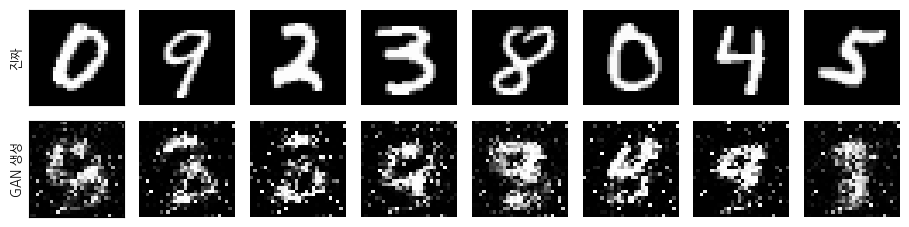

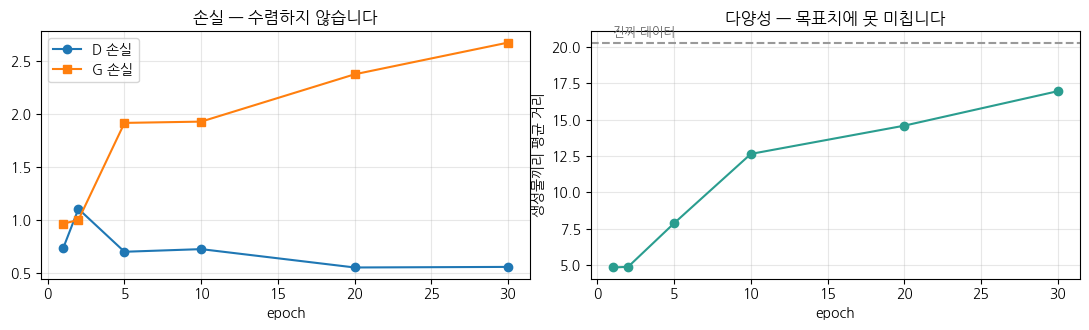

→ 왼쪽: **손실만 보고는 학습이 잘 되는지 알 수 없습니다.**
→ 오른쪽: 다양성은 늘다가 멈춥니다. 진짜(점선)에 닿지 못합니다.

★ **GAN에는 「검증 손실」에 해당하는 것이 없습니다.**
  7장에서 배운 조기 종료·모델 선택이 그대로 통하지 않습니다.
  그래서 실무에서는 **눈으로 보고** 고르거나 별도 지표(FID 등)를 씁니다.


In [6]:
z = np.random.default_rng(0).normal(size=(8, LATENT)).astype("float32")
show([x_train[:8], generate(G, z)], ["진짜", "GAN 생성"])

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ep = [h[0] for h in hist]
ax[0].plot(ep, [h[1] for h in hist], "o-", label="D 손실")
ax[0].plot(ep, [h[2] for h in hist], "s-", label="G 손실")
ax[0].set_xlabel("epoch"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[0].set_title("손실 — 수렴하지 않습니다")
ax[1].plot(ep, [h[3] for h in hist], "o-", color="#2a9d8f")
ax[1].axhline(REAL_DIV, ls="--", color="#999999")
ax[1].annotate("진짜 데이터", (ep[0], REAL_DIV), xytext=(0, 5),
               textcoords="offset points", fontsize=9, color="#666666")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("생성물끼리 평균 거리")
ax[1].grid(alpha=0.3); ax[1].set_title("다양성 — 목표치에 못 미칩니다")
plt.tight_layout(); plt.show()

print("→ 왼쪽: **손실만 보고는 학습이 잘 되는지 알 수 없습니다.**")
print("→ 오른쪽: 다양성은 늘다가 멈춥니다. 진짜(점선)에 닿지 못합니다.")
print()
print("★ **GAN에는 「검증 손실」에 해당하는 것이 없습니다.**")
print("  7장에서 배운 조기 종료·모델 선택이 그대로 통하지 않습니다.")
print("  그래서 실무에서는 **눈으로 보고** 고르거나 별도 지표(FID 등)를 씁니다.")

## 정리

| epoch | D 손실 | G 손실 | 다양성 |
|:--:|:--:|:--:|:--:|
| 1 | 0.736 | 0.968 | 4.84 |
| 5 | 0.757 | 1.806 | 7.98 |
| 10 | 0.834 | 1.597 | 12.41 |
| 20 | 0.723 | 2.182 | 15.73 |
| 30 | 0.582 | 2.216 | 15.64 |
| (진짜) | — | — | **20.29** |

- **★ G 손실이 올라가는데 결과는 좋아집니다.** 지도학습의 직관이 통하지
  않습니다. G의 손실은 **G의 실력이 아니라 둘의 균형**을 잽니다.
- **손실은 수렴하지 않습니다.** 오르내립니다. 그것이 정상입니다.
- **다양성이 목표치에 못 미친 채 멈춥니다** (15.6 대 20.3).
  부분적인 **모드 붕괴**입니다.
- **GAN에는 「검증 손실」에 해당하는 것이 없습니다.** 7장에서 배운
  조기 종료와 모델 선택이 그대로 통하지 않습니다.

### 연습

1. epoch을 60, 100으로 늘리십시오. 다양성이 20.3에 닿습니까.
2. D를 **한 걸음에 두 번** 갱신하십시오. 무엇이 달라집니까.
3. 학습률을 0.001로 올리십시오. 며칠 안에 무너집니까.
4. 생성기의 마지막 활성화를 `tanh` 에서 `sigmoid` 로 바꾸면 어떻게 됩니까.
   (힌트: 데이터의 범위가 [-1, 1] 입니다)
5. **[열린 문제]** 다양성 지표를 클래스별로 재십시오 — 분류기를 하나
   따로 학습시켜 생성물의 숫자를 판정하고, **어떤 숫자가 적게 나오는지**
   보십시오. 그것이 모드 붕괴의 정확한 모습입니다.